In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from itertools import combinations
from scipy.stats import mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests

from rvm_analysis.colours import get_cell_colour

base_save_dir = "../Gaussian_Processes/gpytorch_models/results/gen_pois_no_exp/"
full_data = pd.read_csv(os.path.join(base_save_dir, "combined_data.csv"))

with open("../../saved_files.pkl",'rb') as f:
    files_ON, files_OFF, files_NEUTRAL,files_NEUTRAL_extra = pickle.load(f)
print(files_ON)
print(files_OFF)
combined_files = files_ON
combined_files.extend(files_OFF)
combined_files.extend(files_NEUTRAL)
combined_files.extend(files_NEUTRAL_extra)

full_data['file'] = combined_files
pd.set_option('display.min_rows', 30) 
display(full_data)

np.random.seed(0)

['CA_ongoing01a_cut_pared', 'CA_ongoing01a_cut_pared', 'CA_ongoing01a_cut_pared', 'CA_ongoing01a_cut_pared', 'CA_ongoing02a_cut_pared', 'CA_ongoing02a_cut_pared', 'CA_ongoing02b_cut_pared', 'CA_ongoing02c_cut_pared', 'CA_ongoing02c_cut_pared', 'CA_ongoing05a_cut_pared', 'CA_ongoing05b_cut_pared', 'CA_ongoing06a_cut_pared', 'CA_ongoing06a_cut_pared', 'CA_ongoing08a_cut_pared', 'CA_ongoing08a_cut_pared', 'Naive 4-16-24 a ON@2390_cut_pared', 'Naive 4-16-24 b ON@2765_cut_pared', 'Naive 4-16-24 c OFF&ON@2935_cut_pared', 'ZS Naive 4-17-24 a ON@1695_cut_pared', 'ZS Naive 4-18-24 #1 ON&OFF@2120_cut_pared', 'ZS Naive 4-23-24a ON@2249_cut_pared', 'ZS Naive 4-23-24b OFF&ON@3244_cut_pared', 'ZS Naive 4-25-24a ON@2646_cut_pared', 'ZS Naive 4-30-24b ON@2455_cut_pared', 'ZS Naive 5-1-24c ON@2934_cut_pared']
['CA_ongoing01a_cut_pared', 'CA_ongoing01b_cut_pared', 'CA_ongoing03a_cut_pared', 'CA_ongoing03b_cut_pared', 'CA_ongoing04a_cut_pared', 'CA_ongoing04b_cut_pared', 'CA_ongoing04b_cut_pared', 'CA_on

,model_id,cell_name,id,lengthscale,period_length,outputscale,w,noise_prob,Train Model ELPD,Train Mean Model ELPD,Train Pseudo-R2,Test Model ELPD,Test Mean Model ELPD,Test Pseudo-R2,file
0,ON_0,ON,0,0.732044,290.712268,4.606016,0.768903,0.01,-1072.999699,-1133.894164,0.053704,-276.230380,-300.670083,0.081284,CA_ongoing01a_cut_pared
1,ON_1,ON,1,0.740650,289.767818,5.607834,0.779566,0.01,-1018.859827,-1146.362970,0.111224,-252.214763,-261.949199,0.037162,CA_ongoing01a_cut_pared
2,ON_2,ON,2,0.744271,290.009250,6.764927,0.698850,0.01,-1315.033348,-1365.557008,0.036999,-290.361363,-305.768099,0.050387,CA_ongoing01a_cut_pared
3,ON_3,ON,3,0.721765,298.802854,1.141226,0.743137,0.01,-621.427217,-642.321655,0.032530,-149.273492,-151.335355,0.013624,CA_ongoing01a_cut_pared
4,ON_4,ON,4,0.724499,293.381321,8.326621,0.304734,0.01,-975.930450,-1207.285914,0.191633,-275.297060,-290.031694,0.050804,CA_ongoing02a_cut_pared
5,ON_5,ON,5,0.744238,295.889293,4.348019,0.448315,0.01,-915.856375,-1114.256206,0.178056,-282.327544,-266.298665,-0.060191,CA_ongoing02a_cut_pared
6,ON_6,ON,6,0.721077,287.739731,12.198110,0.716510,0.01,-920.409806,-1132.974297,0.187616,-269.585670,-325.676262,0.172228,CA_ongoing02b_cut_pared
7,ON_7,ON,7,0.734141,289.869265,99.440886,0.848059,0.01,-1171.103623,-1687.556068,0.306036,-294.444502,-455.350525,0.353367,CA_ongoing02c_cut_pared
8,ON_8,ON,8,0.706021,288.619532,24.066045,0.189893,0.01,-909.192650,-1198.124463,0.241153,-268.362960,-356.380378,0.246976,CA_ongoing02c_cut_pared
9,ON_9,ON,9,0.705061,286.237229,13.749907,0.352465,0.01,-1162.689404,-1191.366788,0.024071,-302.573546,-312.177159,0.030763,CA_ongoing05a_cut_pared



Observed median pseudo R²: 0.0372
Permutation test p-value (two-sided, median not equal to 0): 0.0067

Observed median pseudo R²: 0.0187
Permutation test p-value (two-sided, median not equal to 0): 0.3127

Observed median pseudo R²: -0.0128
Permutation test p-value (two-sided, median not equal to 0): 0.0033

Observed median pseudo R²: 0.0448
Permutation test p-value (two-sided, median not equal to 0): 0.0047

Observed median pseudo R²: 0.0479
Permutation test p-value (two-sided, median not equal to 0): 0.0004

Observed median pseudo R²: 0.0281
Permutation test p-value (two-sided, median not equal to 0): 0.0000


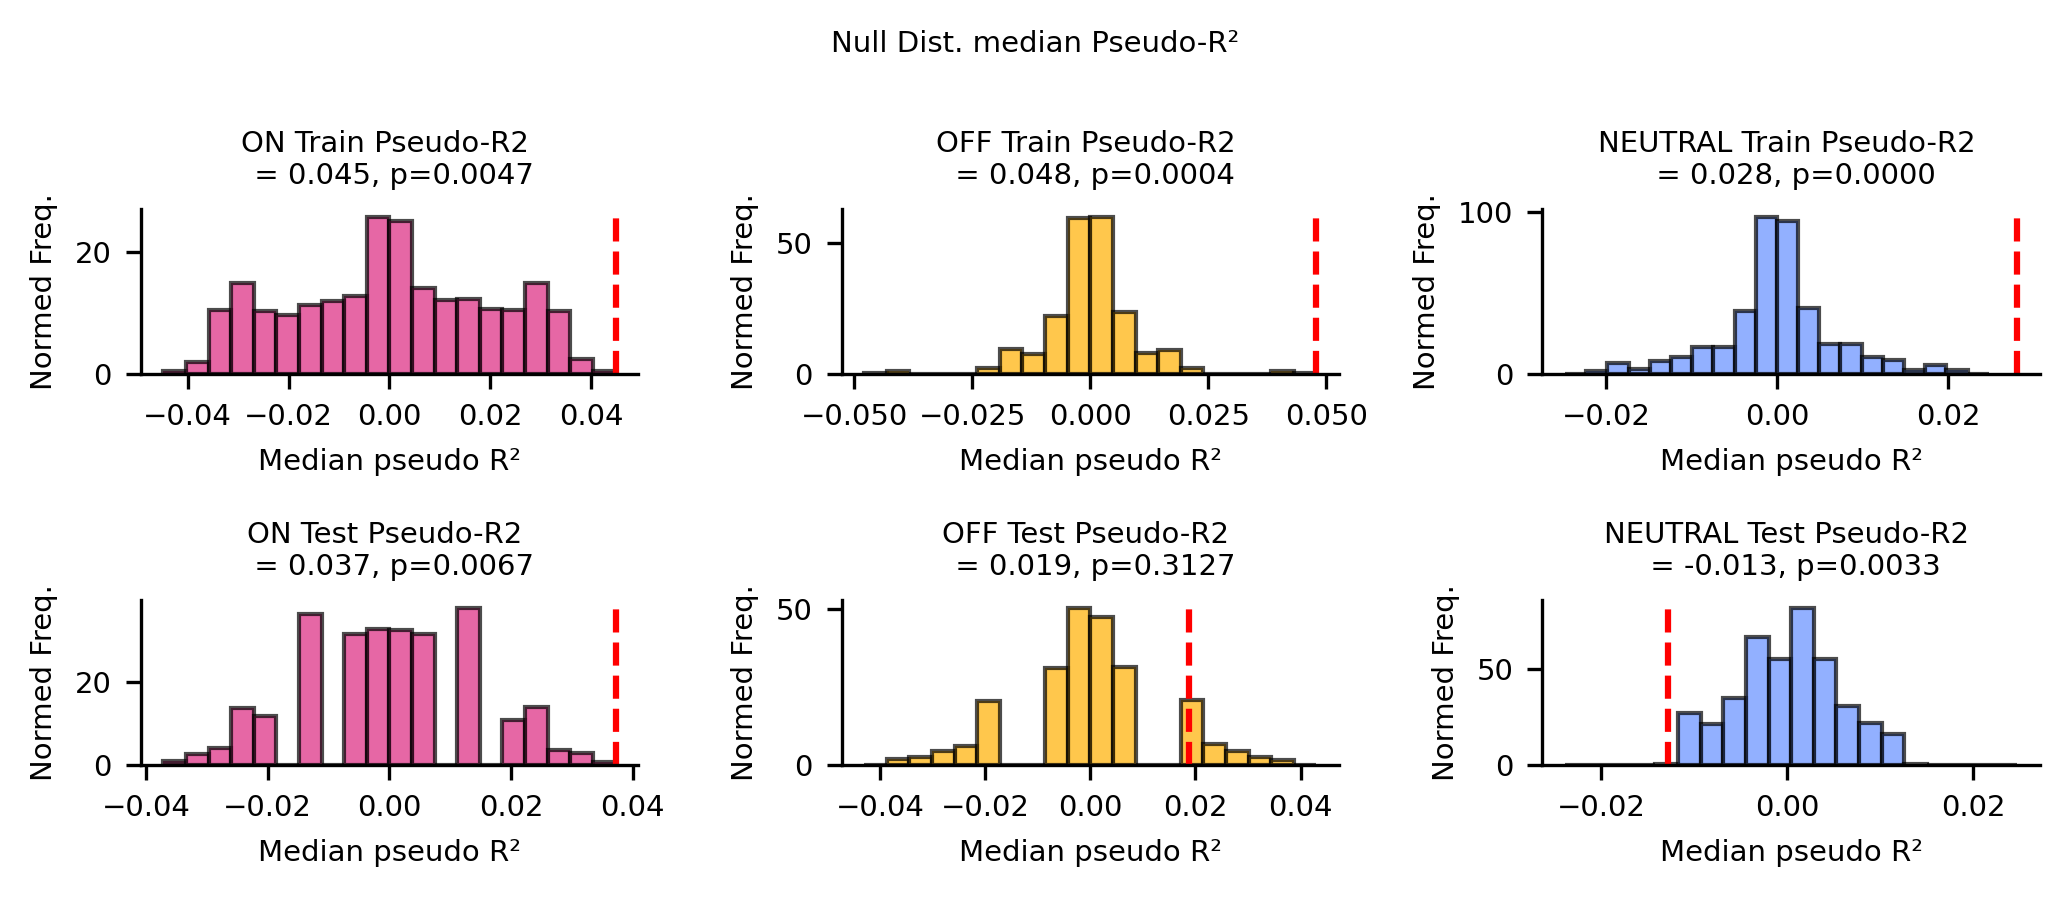

In [ ]:
def compute_bootstrap_metric(full_data, cell_type='ON', metric='Test Pseudo-R2', ax=None,metric_name=None):
    # get data by cell type
    cell_type_specific_results = full_data[full_data['cell_name'] == cell_type]
    data = cell_type_specific_results[["file", metric]]

    observed_median = np.median(data[metric])
    print(f"\nObserved median pseudo R²: {observed_median:.4f}")

    # Clustered permutation test (flip signs)
    n_permutations = 10000
    null_medians = []

    # Group R2s by file (not always animal, but usually - just cells recorded together)
    grouped = data.groupby('file')
    animal_to_R2 = {animal: group[metric].values for animal, group in grouped}
    animal_ids = list(animal_to_R2.keys())

    for _ in range(n_permutations):
        permuted_R2s = []
        for animal in animal_ids:
            flip = np.random.choice([1, -1])  # flip all or none for this group
            permuted_R2s.extend(flip * animal_to_R2[animal])
        null_medians.append(np.median(permuted_R2s))

    null_medians = np.array(null_medians)

    # Two-sided p-value (H0: median = 0)
    p_value = np.mean(np.abs(null_medians) >= abs(observed_median))

    print(f"Permutation test p-value (two-sided, median not equal to 0): {p_value:.4f}")

    # Plot null distribution
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    ax: Axes = ax
    ax.spines[["right", "top"]].set_visible(False)
    ax.hist(null_medians, alpha=0.7, color=get_cell_colour(names=cell_type), edgecolor='black',density=True,
            bins=20)
    ax.axvline(observed_median, color='red', linestyle='--', label='Observed median')
    # ax.axvline(-observed_median, color='red', linestyle='--', alpha=0.5)
    ax.set_title(f'{cell_type} {metric if metric_name is None else metric_name} \n = {observed_median:.3f}, p={p_value:.4f}', fontsize=7)
    ax.set_xlabel('Median pseudo R²', fontsize=7)
    ax.set_ylabel('Normed Freq.', fontsize=7)
    ax.tick_params(labelsize=7)
    # ax.legend(fontsize=7)

fig, ax = plt.subplots(2, 3, figsize=(7, 3),dpi=300)
ax = ax.flatten()
compute_bootstrap_metric(full_data, cell_type='ON', metric='Test Pseudo-R2', ax=ax[3])
compute_bootstrap_metric(full_data, cell_type='OFF', metric='Test Pseudo-R2', ax=ax[4])
compute_bootstrap_metric(full_data, cell_type='NEUTRAL', metric='Test Pseudo-R2', ax=ax[5])

compute_bootstrap_metric(full_data, cell_type='ON', metric='Train Pseudo-R2', ax=ax[0])
compute_bootstrap_metric(full_data, cell_type='OFF', metric='Train Pseudo-R2', ax=ax[1])
compute_bootstrap_metric(full_data, cell_type='NEUTRAL', metric='Train Pseudo-R2', ax=ax[2])
plt.suptitle("Null Dist. median Pseudo-R²",fontsize=7)
plt.tight_layout()
plt.show()



Observed median pseudo R²: 0.7319
Permutation test p-value (two-sided, median not equal to 0): 0.0011

Observed median pseudo R²: 0.4327
Permutation test p-value (two-sided, median not equal to 0): 0.0105

Observed median pseudo R²: -0.8572
Permutation test p-value (two-sided, median not equal to 0): 0.0000


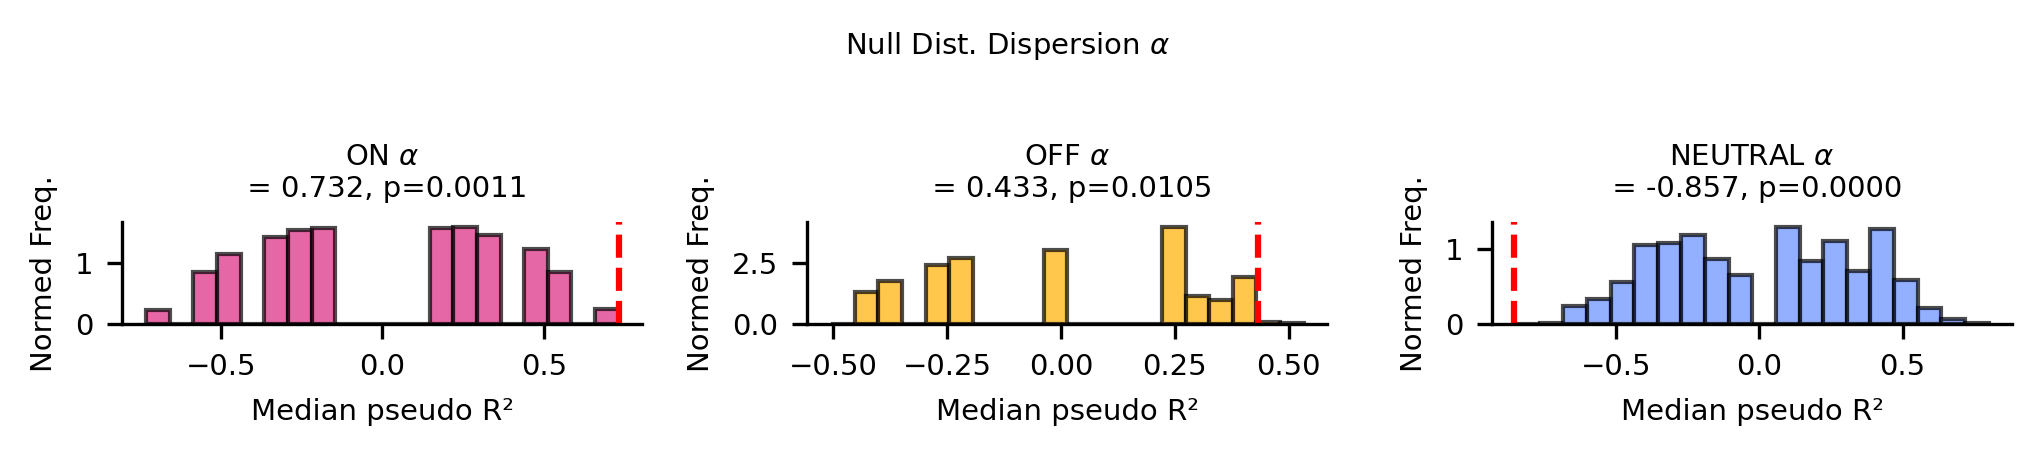

In [22]:
np.random.seed(1)
fig, ax = plt.subplots(1,3, figsize=(7, 1.5),dpi=300)
ax = ax.flatten()
compute_bootstrap_metric(full_data, cell_type='ON', metric='w', ax=ax[0],metric_name="$\\alpha$")
compute_bootstrap_metric(full_data, cell_type='OFF', metric='w', ax=ax[1],metric_name="$\\alpha$")
compute_bootstrap_metric(full_data, cell_type='NEUTRAL', metric='w', ax=ax[2],metric_name="$\\alpha$")
plt.suptitle("Null Dist. Dispersion $\\alpha$",fontsize=7)
plt.tight_layout()
plt.show()

(23.591769027328837, 0.203)

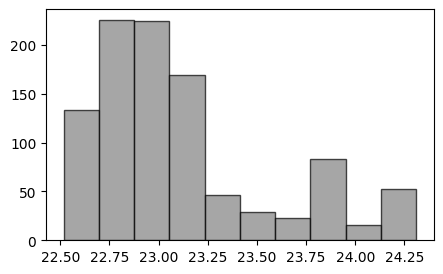

In [ ]:
def clustered_kruskal_wallis(df, value_col='r2', group_col='cell_type', cluster_col='animal', n_permutations=1000):
    """ Kruskal Wallis, clustering by cells recorded together (same file). """
    # Compute observed H-statistic
    observed_groups = [group[value_col].values for name, group in df.groupby(group_col)]
    observed_stat, _ = kruskal(*observed_groups)

    # Permutation test: shuffle cell_type labels within each group.
    permuted_stats = []
    for _ in range(n_permutations):
        df_permuted = df.copy()
        df_permuted[group_col] = (
            df.groupby(cluster_col)[group_col]
              .transform(lambda x: np.random.permutation(x.values))
        )
        perm_groups = [group[value_col].values for name, group in df_permuted.groupby(group_col)]
        
        # Only compute if all groups are present
        if all(len(g) > 0 for g in perm_groups):
            perm_stat, _ = kruskal(*perm_groups)
            permuted_stats.append(perm_stat)

    # Compute empirical p-value
    permuted_stats = np.array(permuted_stats)
    p_value = np.mean(permuted_stats >= observed_stat)

    fig, ax = plt.subplots(figsize=(5,3))
    plt.hist(permuted_stats, alpha=0.7, color='gray', edgecolor='black')

    return observed_stat, p_value


clustered_kruskal_wallis(full_data,value_col="Test Pseudo-R2",group_col='cell_name',cluster_col='file')

In [ ]:

def clustered_mannwhitney_u(df, group_col='cell_type', value_col='r2', cluster_col='animal',
                             group1='A', group2='B', n_permutations=1000, alternative='two-sided'):
    # Subset to two groups
    df_pair = df[df[group_col].isin([group1, group2])].copy()

    # Compute observed statistic
    vals1 = df_pair[df_pair[group_col] == group1][value_col]
    vals2 = df_pair[df_pair[group_col] == group2][value_col]
    observed_u, _ = mannwhitneyu(vals1, vals2, alternative=alternative)

    # Get null distribution via permutations
    perm_stats = []
    for _ in range(n_permutations):
        df_shuffled = df_pair.copy()

        # Shuffle group labels within each animal
        df_shuffled[group_col] = (
            df_shuffled.groupby(cluster_col)[group_col]
            .transform(lambda x: np.random.permutation(x.values))
        )

        # Assign new group values
        try:
            vals1_perm = df_shuffled[df_shuffled[group_col] == group1][value_col]
            vals2_perm = df_shuffled[df_shuffled[group_col] == group2][value_col]
            
            # Skip permutations that drop a group
            if len(vals1_perm) == 0 or len(vals2_perm) == 0:
                continue

            perm_u, _ = mannwhitneyu(vals1_perm, vals2_perm, alternative=alternative)
            perm_stats.append(perm_u)
        except ValueError:
            continue

    # Calculate p-value
    perm_stats = np.array(perm_stats)
    if alternative == 'greater':
        p = np.mean(perm_stats >= observed_u)
    elif alternative == 'less':
        p = np.mean(perm_stats <= observed_u)
    else:  # two-sided
        p = np.mean(np.abs(perm_stats - np.median(perm_stats)) >= np.abs(observed_u - np.median(perm_stats)))

    print(f"{group1} vs {group2}: u={observed_u}, p= {p}")

    return observed_u, p


clustered_mannwhitney_u(full_data,value_col="Test Pseudo-R2",group_col='cell_name',cluster_col='file',
                        group1='ON',group2='OFF',alternative="two-sided")
clustered_mannwhitney_u(full_data,value_col="Test Pseudo-R2",group_col='cell_name',cluster_col='file',
                        group1='ON',group2='NEUTRAL',alternative="two-sided")
clustered_mannwhitney_u(full_data,value_col="Test Pseudo-R2",group_col='cell_name',cluster_col='file',
                        group1='OFF',group2='NEUTRAL',alternative="two-sided")

ON vs OFF: u=369.0, p= 0.313
ON vs NEUTRAL: u=695.0, p= 1.0
OFF vs NEUTRAL: u=599.0, p= 1.0


(599.0, 1.0)

# Trying a block level permutation

In [ ]:

def permute_cell_type_blocks(df,cluster_col='file',group_col='cell_name'):
    df_perm = df.copy()
    for animal, group in df.groupby(cluster_col):
        labels = group[group_col].unique()
        permuted_labels = np.random.permutation(labels)
        label_map = dict(zip(labels, permuted_labels))
        df_perm.loc[group.index, group_col] = group[group_col].map(label_map)
    return df_perm

def permute_cell_type_blocks_with_full_label_space(df, cluster_col='file', group_col='cell_name',
                                                   label_set = ['ON','OFF','NEUTRAL']):
    df_perm = df.copy()
    
    for animal, group in df.groupby(cluster_col):
        # permute labels used in this animal
        original_labels = group[group_col].unique()
        permuted_labels = np.random.permutation(label_set)
        
        # Map original labels to the beginning of that permutation
        label_map = dict(zip(original_labels, permuted_labels[:len(original_labels)]))
        
        # Apply mapping within this animal only
        df_perm.loc[group.index, group_col] = group[group_col].map(label_map)
    
    return df_perm


def kruskal_blockwise(df, n_perm=1000, seed=None,group_col='cell_name',cluster_col='file',metric='Test Pseudo-R2',
                      ax=None):
    np.random.seed(seed)
    
    # Observed test stat
    groups = [df[df[group_col] == ct][metric] for ct in df[group_col].unique()]
    H_obs, _ = kruskal(*groups)

    # Permuted test stats
    H_perm = []
    for _ in range(n_perm):
        df_perm = permute_cell_type_blocks_with_full_label_space(df,cluster_col,group_col)
        groups_perm = [df_perm[df_perm[group_col] == ct][metric] for ct in df[group_col].unique()]
        try:
            H, _ = kruskal(*groups_perm)
            H_perm.append(H)
        except ValueError:
            pass  # skip invalid permutation
    if ax is None:
        fig, ax = plt.subplots()
    ax.hist(H_perm,density=True)
    ax.spines[["top","right"]].set_visible(False)
    ax.tick_params(labelsize=7)
    ax.set_title(metric,fontsize=7)
    ax.vlines(H_obs,*ax.get_ylim(),color='red',linestyle='--')
    p = np.mean([H >= H_obs for H in H_perm])
    ax.legend([f"p={p}"],fontsize=7)
    return H_obs, p


In [ ]:
def mannwhitney_blockwise(df, group1, group2, n_perm=1000, seed=None, alternative='two-sided',
                          group_col='cell_name',cluster_col='file',metric='Test Pseudo-R2',ax=None):
    np.random.seed(seed)

    df_sub = df[df[group_col].isin([group1, group2])]
    r1 = df_sub[df_sub[group_col] == group1][metric]
    r2 = df_sub[df_sub[group_col] == group2][metric]
    U_obs, _ = mannwhitneyu(r1, r2, alternative=alternative)

    U_perm = []
    for _ in range(n_perm):
        df_perm = permute_cell_type_blocks_with_full_label_space(df_sub,label_set=[group1,group2])
        r1_perm = df_perm[df_perm[group_col] == group1][metric]
        r2_perm = df_perm[df_perm[group_col] == group2][metric]
        if len(r1_perm) > 0 and len(r2_perm) > 0:
            U, _ = mannwhitneyu(r1_perm, r2_perm, alternative=alternative)
            U_perm.append(U)

    if alternative == 'two-sided':
        p = np.mean([abs(u - np.median(U_perm)) >= abs(U_obs - np.median(U_perm)) for u in U_perm])
    elif alternative == 'greater':
        p = np.mean([U >= U_obs for U in U_perm])
    else:
        p = np.mean([U <= U_obs for U in U_perm])

    if ax is None:
        fig, ax = plt.subplots()
    ax.tick_params(labelsize=7)
    ax.hist(U_perm,density=True)
    ax.set_xlabel("Mann Whitney U stat.",fontsize=7)
    ax.set_ylabel("Freq. (normed)",fontsize=7)
    ax: Axes=ax
    ax.set_title(f"{metric}\n{group1} vs {group2}",fontsize=7)
    ax.spines[["right","top"]].set_visible(False)
    ax.vlines(U_obs,*ax.get_ylim(),linestyle='--',color='red')
    return U_obs, p


Kruskal-Wallis H = 23.592, p = 0
Kruskal-Wallis H = 4.814, p = 0.117


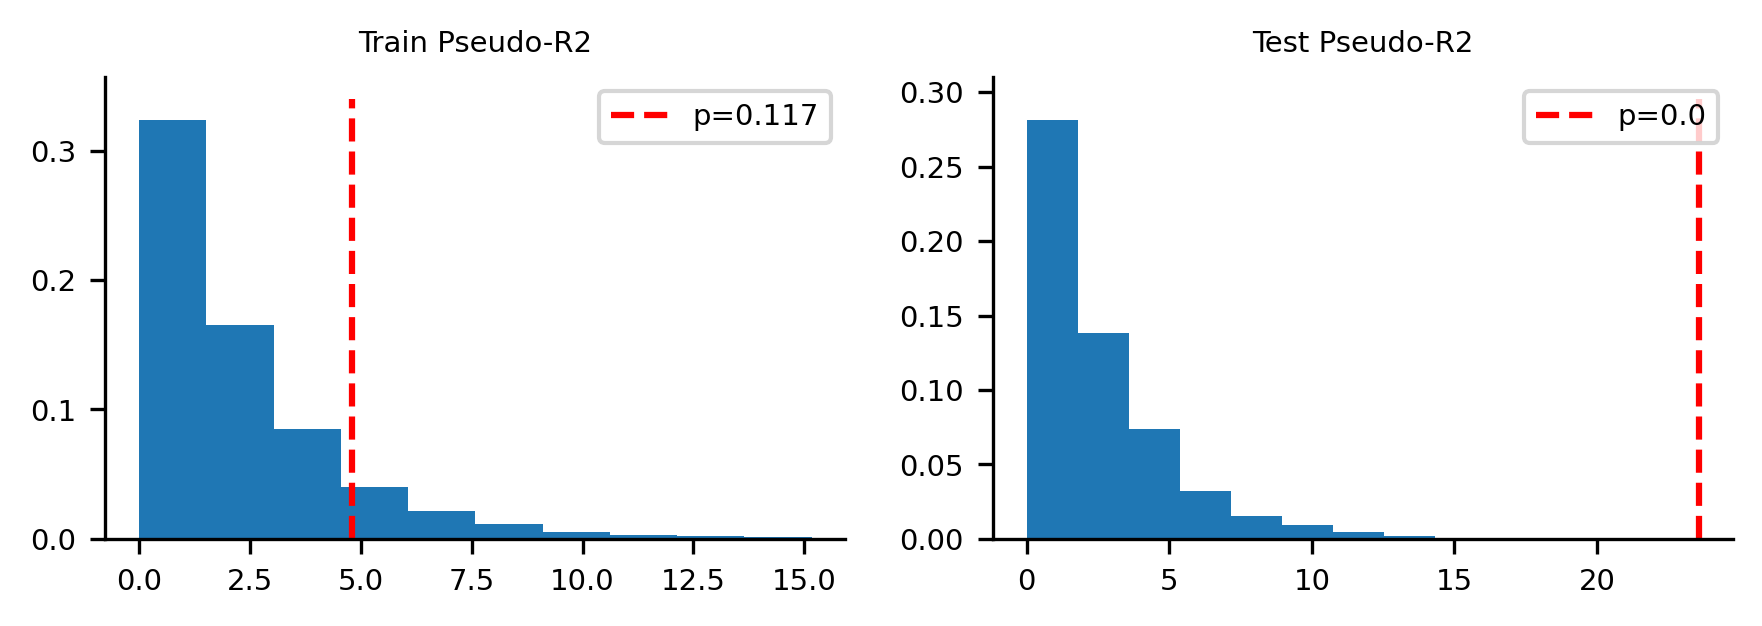

In [27]:
# Kruskal-Wallis
fig, ax = plt.subplots(1,2,figsize=(7,2),dpi=300)

N_perm_kruskal = 1000

H, p_kw = kruskal_blockwise(full_data, n_perm=N_perm_kruskal, ax=ax[1], seed=42)
print(f"Kruskal-Wallis H = {H:.3f}, p = {p_kw:.4g}")


H, p_kw = kruskal_blockwise(full_data, n_perm=N_perm_kruskal, ax=ax[0], seed=42,metric='Train Pseudo-R2')
print(f"Kruskal-Wallis H = {H:.3f}, p = {p_kw:.4g}")



Mann-Whitney test ON vs OFF: U = 369.000, p = 0.3130
Mann-Whitney test ON vs NEUTRAL: U = 695.000, p = 0.0000
Mann-Whitney test OFF vs NEUTRAL: U = 599.000, p = 0.0020
Mann-Whitney train ON vs OFF: U = 338.000, p = 0.5800
Mann-Whitney train ON vs NEUTRAL: U = 525.000, p = 0.0470
Mann-Whitney train OFF vs NEUTRAL: U = 501.000, p = 0.1100


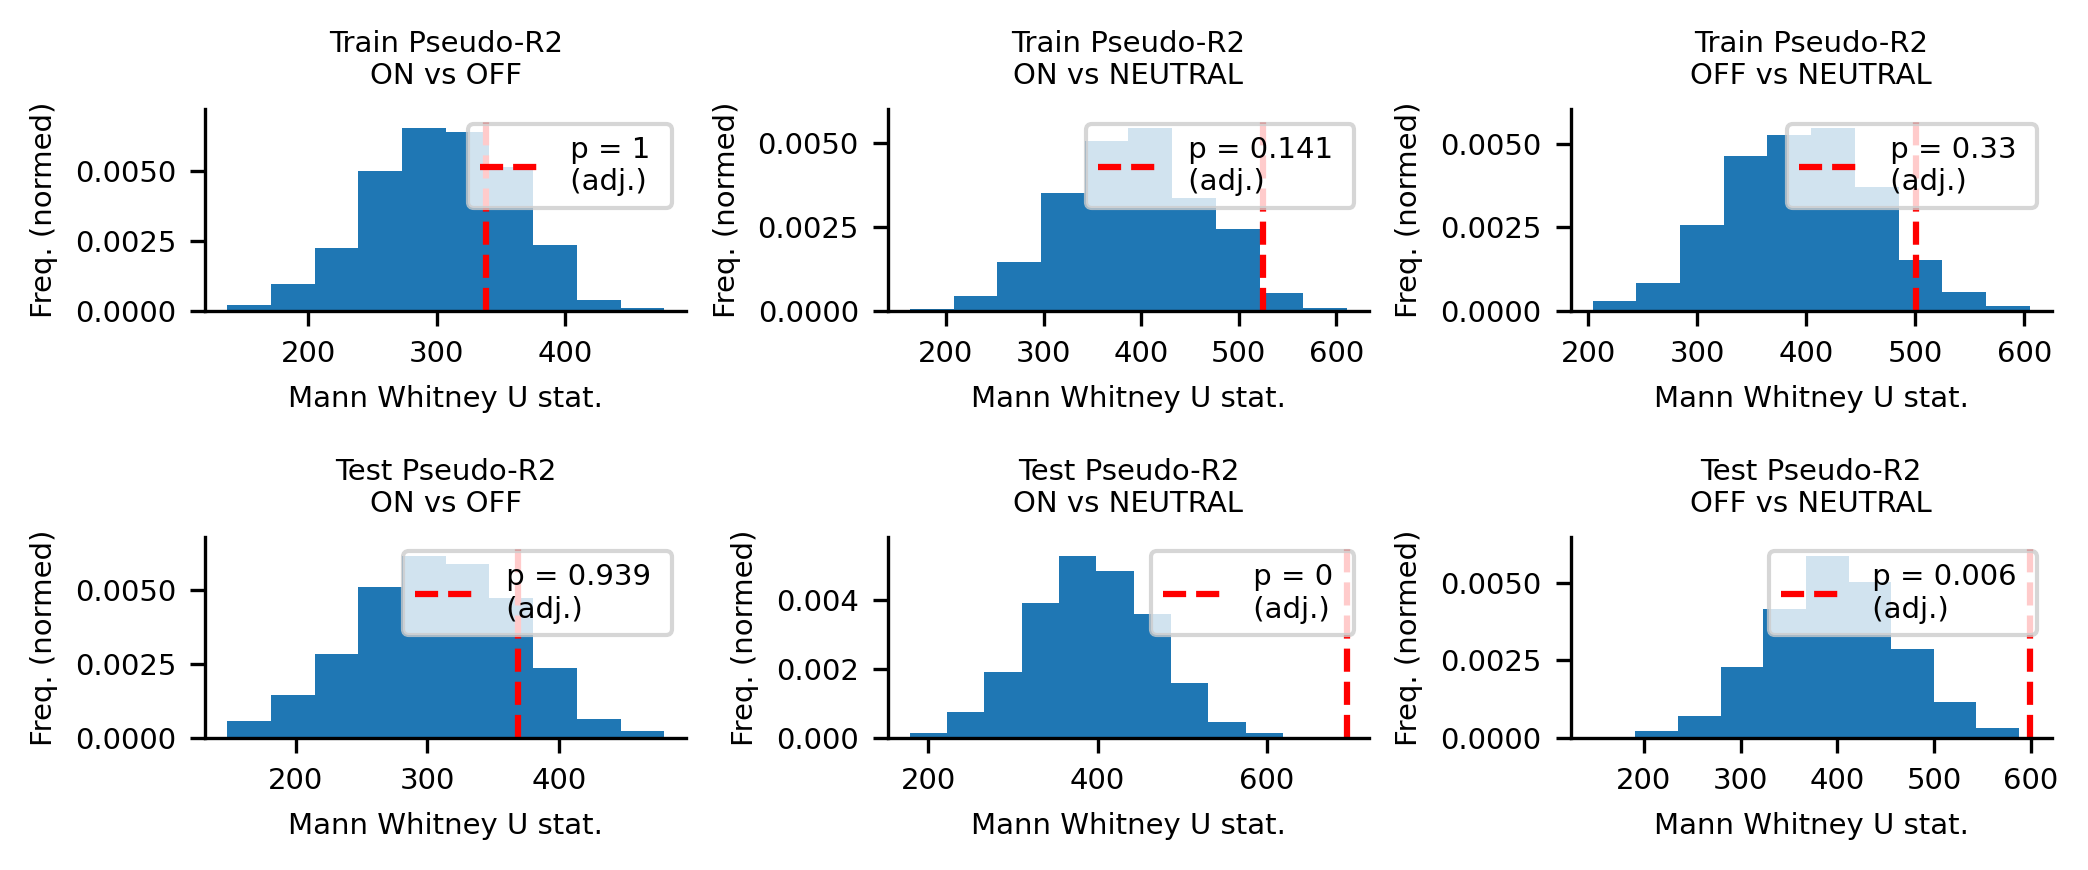

In [ ]:
fig, ax = plt.subplots(2,3,figsize=(7,3),dpi=300)
ax = ax.flatten()

# Pairwise Mann-Whitney
N_perm = 1000

p_vals = []
for i, (g1, g2) in enumerate(combinations(['ON', 'OFF', 'NEUTRAL'], 2)):
    U, p = mannwhitney_blockwise(full_data, g1, g2, n_perm=N_perm, seed=42, alternative='two-sided',
                                 ax=ax[i+3],metric='Test Pseudo-R2')
    print(f"Mann-Whitney test {g1} vs {g2}: U = {U:.3f}, p = {p:.4f}")
    p_vals.append(p)

# Bonferroni corrected
reject_test, pvals_corrected_test, _, _ = multipletests(p_vals, method='bonferroni')


p_vals = []
for i, (g1, g2) in enumerate(combinations(['ON', 'OFF', 'NEUTRAL'], 2)):
    U, p = mannwhitney_blockwise(full_data, g1, g2, n_perm=N_perm, seed=42, alternative='two-sided',
                                 metric='Train Pseudo-R2',ax=ax[i])
    p_vals.append(p)
    print(f"Mann-Whitney train {g1} vs {g2}: U = {U:.3f}, p = {p:.4f}")

# Bonferroni corrected
reject_train, pvals_corrected_train, _, _ = multipletests(p_vals, method='bonferroni')

pvals_combined = list(pvals_corrected_train)
pvals_combined.extend(pvals_corrected_test)
for j, a in enumerate(ax):
    a.legend([f" p = {pvals_combined[j]:.4g} \n (adj.)"],fontsize=7)

plt.tight_layout()
plt.show()